# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

alpha = 0.944 ± 0.151
beta  = 5.902 ± 0.112


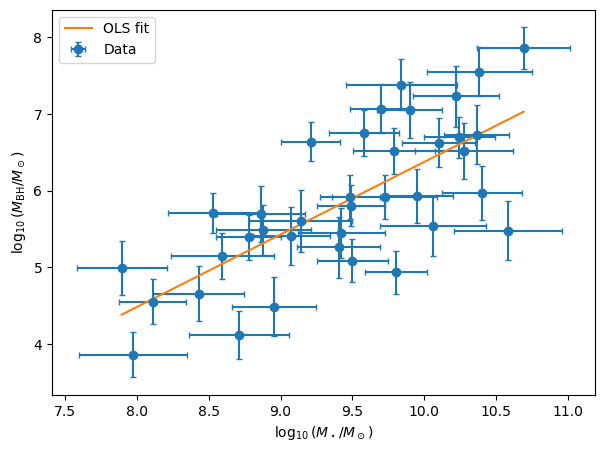

In [2]:
# Part 1: your work here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/siyaoxu2.csv")

x = df["logMstar"].to_numpy()
sx = df["err_logMstar"].to_numpy()

y = df["logMBH"].to_numpy()
sy = df["err_logMBH"].to_numpy()

xp = x - 9.5

A = np.column_stack([xp, np.ones(len(x))])

theta_hat = np.linalg.solve(A.T @ A, A.T @ y)

alpha_hat = theta_hat[0]
beta_hat = theta_hat[1]

y_model = A @ theta_hat
residuals = y - y_model

RSS = np.sum(residuals**2)

N = len(y)

s2 = RSS / (N - 2)

cov = s2 * np.linalg.inv(A.T @ A)

sigma_alpha = np.sqrt(cov[0, 0])
sigma_beta = np.sqrt(cov[1, 1])

print(f"alpha = {alpha_hat:.3f} ± {sigma_alpha:.3f}")
print(f"beta  = {beta_hat:.3f} ± {sigma_beta:.3f}")

plt.figure(figsize=(7, 5))

plt.errorbar(
    x, y,
    xerr=sx,
    yerr=sy,
    fmt='o',
    capsize=2,
    label='Data'
)

xgrid = np.linspace(x.min(), x.max(), 200)
ygrid = alpha_hat * (xgrid - 9.5) + beta_hat

plt.plot(
    xgrid,
    ygrid,
    label='OLS fit'
)

plt.xlabel(r'$\log_{10}(M_\star/M_\odot)$')
plt.ylabel(r'$\log_{10}(M_{\rm BH}/M_\odot)$')
plt.legend()
plt.show()

**ANSWER (a few sentences):**

*your answer goes here*

The standard OLS assumptions are not fully satisfied because both variables have
measurement uncertainties, while OLS assumes that the predictor variable is
measured without error. The uncertainties are also different for different
galaxies, and there is intrinsic astrophysical scatter that is not explicitly
modeled by this fit.

The measurement errors in $x$ produce attenuation bias (regression dilution),
which tends to pull the fitted slope toward zero. The size of this bias depends
on the size of the $x$ measurement-error variance relative to the intrinsic
spread of the true $x$ values: larger $x$ uncertainties or a narrower intrinsic
$x$ distribution produce stronger attenuation.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

WLS
alpha = 0.974 ± 0.071
beta  = 5.942 ± 0.053

ODR
alpha = 1.378 ± 0.193
beta  = 5.951 ± 0.123

Optimization success: True
Optimization terminated successfully.

Generative model
alpha     = 1.140 ± 0.183
beta      = 5.921 ± 0.112
sigma_int = 0.494 ± 0.106 dex

mu        = 9.459
sigma_pop = 0.673


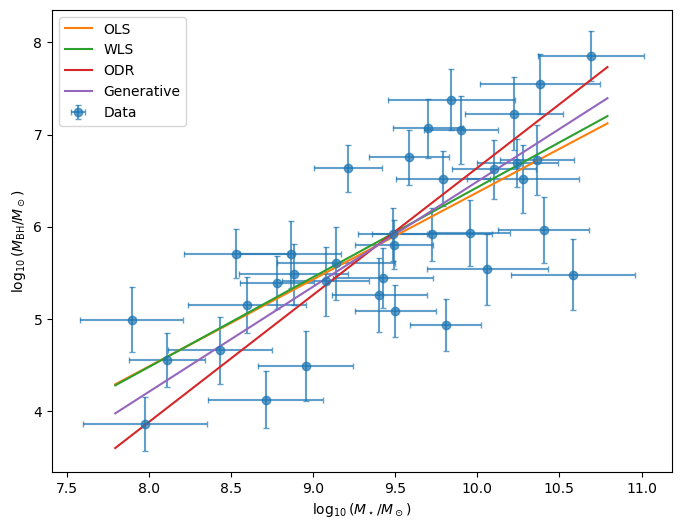

In [3]:
# Part 2: your work here
import numpy as np
import matplotlib.pyplot as plt

from scipy import odr
from scipy.optimize import minimize


w = 1.0 / sy**2

cov_wls = np.linalg.inv(A.T @ (w[:, None] * A))

theta_wls = cov_wls @ (A.T @ (w * y))

alpha_wls = theta_wls[0]
beta_wls = theta_wls[1]

sigma_alpha_wls = np.sqrt(cov_wls[0, 0])
sigma_beta_wls = np.sqrt(cov_wls[1, 1])


print("WLS")
print(f"alpha = {alpha_wls:.3f} ± {sigma_alpha_wls:.3f}")
print(f"beta  = {beta_wls:.3f} ± {sigma_beta_wls:.3f}")
print()

def odr_model(B, xp):
    alpha, beta = B
    return alpha * xp + beta


model = odr.Model(odr_model)

data_odr = odr.RealData(
    x - 9.5,
    y,
    sx=sx,
    sy=sy
)

odr_fit = odr.ODR(
    data_odr,
    model,
    beta0=[alpha_hat, beta_hat]
)

odr_result = odr_fit.run()

alpha_odr, beta_odr = odr_result.beta
sigma_alpha_odr, sigma_beta_odr = odr_result.sd_beta


print("ODR")
print(f"alpha = {alpha_odr:.3f} ± {sigma_alpha_odr:.3f}")
print(f"beta  = {beta_odr:.3f} ± {sigma_beta_odr:.3f}")
print()

def neg_loglike(params):

    alpha, beta, log_sigma_int, mu, log_sigma_pop = params

    sigma_int = np.exp(log_sigma_int)
    sigma_pop = np.exp(log_sigma_pop)

    total = 0.0

    mean = np.array([
        mu,
        alpha * (mu - 9.5) + beta
    ])

    for xi, yi, sxi, syi in zip(x, y, sx, sy):

        S = np.array([
            [
                sigma_pop**2 + sxi**2,
                alpha * sigma_pop**2
            ],
            [
                alpha * sigma_pop**2,
                alpha**2 * sigma_pop**2
                + sigma_int**2
                + syi**2
            ]
        ])

        z = np.array([xi, yi]) - mean

        sign, logdet = np.linalg.slogdet(S)

        if sign <= 0:
            return np.inf

        total += 0.5 * (
            logdet
            + z @ np.linalg.solve(S, z)
            + 2 * np.log(2 * np.pi)
        )

    return total


sigma_pop_guess = np.sqrt(
    max(
        np.var(x, ddof=1) - np.mean(sx**2),
        0.1**2
    )
)

p0 = np.array([
    alpha_odr,             # alpha
    beta_odr,              # beta
    np.log(0.3),           # log sigma_int
    np.mean(x),            # mu
    np.log(sigma_pop_guess)
])


result = minimize(
    neg_loglike,
    p0,
    method="BFGS",
    options={"maxiter": 10000}
)

print("Optimization success:", result.success)
print(result.message)
print()


p_hat = result.x

alpha_gen = p_hat[0]
beta_gen = p_hat[1]
sigma_int_gen = np.exp(p_hat[2])
mu_gen = p_hat[3]
sigma_pop_gen = np.exp(p_hat[4])

def numerical_hessian(f, p, rel_step=1e-4):

    p = np.asarray(p, dtype=float)
    n = len(p)

    H = np.zeros((n, n))

    h = rel_step * np.maximum(1.0, np.abs(p))

    f0 = f(p)

    for i in range(n):

        ei = np.zeros(n)
        ei[i] = h[i]

        H[i, i] = (
            f(p + ei)
            - 2 * f0
            + f(p - ei)
        ) / h[i]**2

        for j in range(i + 1, n):

            ej = np.zeros(n)
            ej[j] = h[j]

            H[i, j] = (
                f(p + ei + ej)
                - f(p + ei - ej)
                - f(p - ei + ej)
                + f(p - ei - ej)
            ) / (4 * h[i] * h[j])

            H[j, i] = H[i, j]

    return H


H = numerical_hessian(neg_loglike, p_hat)

cov_gen = np.linalg.inv(H)

sigma_alpha_gen = np.sqrt(cov_gen[0, 0])
sigma_beta_gen = np.sqrt(cov_gen[1, 1])

sigma_sigma_int_gen = (
    sigma_int_gen * np.sqrt(cov_gen[2, 2])
)


print("Generative model")
print(f"alpha     = {alpha_gen:.3f} ± {sigma_alpha_gen:.3f}")
print(f"beta      = {beta_gen:.3f} ± {sigma_beta_gen:.3f}")
print(
    f"sigma_int = {sigma_int_gen:.3f} "
    f"± {sigma_sigma_int_gen:.3f} dex"
)
print()

print(f"mu        = {mu_gen:.3f}")
print(f"sigma_pop = {sigma_pop_gen:.3f}")


xgrid = np.linspace(x.min() - 0.1, x.max() + 0.1, 300)

y_ols = alpha_hat * (xgrid - 9.5) + beta_hat
y_wls = alpha_wls * (xgrid - 9.5) + beta_wls
y_odr = alpha_odr * (xgrid - 9.5) + beta_odr
y_gen = alpha_gen * (xgrid - 9.5) + beta_gen


plt.figure(figsize=(8, 6))

plt.errorbar(
    x,
    y,
    xerr=sx,
    yerr=sy,
    fmt='o',
    capsize=2,
    alpha=0.7,
    label='Data'
)

plt.plot(xgrid, y_ols, label='OLS')
plt.plot(xgrid, y_wls, label='WLS')
plt.plot(xgrid, y_odr, label='ODR')
plt.plot(xgrid, y_gen, label='Generative')

plt.xlabel(r'$\log_{10}(M_\star/M_\odot)$')
plt.ylabel(r'$\log_{10}(M_{\rm BH}/M_\odot)$')

plt.legend()
plt.show()

#1. WLS accounts for the different measurement uncertainties in $y$, so points 
# with smaller $\sigma_y$ receive more weight. However, it does not correct the
# attenuation bias from Part 1 because the measurement errors in $x$ are still
# ignored. Therefore the WLS slope can still be biased toward zero.

#2. ODR accounts for uncertainties in both $x$ and $y$, so it can reduce the
# attenuation bias caused by $x$ measurement errors. However, this ODR fit does
# not contain a separate intrinsic-scatter parameter. It effectively explains
# the displacement of points using their quoted measurement errors rather than
# the additional astrophysical scatter in $y$ at fixed true $x$. That assumption
# is not appropriate for these data because the relation explicitly has
# intrinsic scatter.



**FINAL ANSWER:** $\alpha = $ 1.140 $\pm$ 0.183 , $\beta = $ 5.921 $\pm$ 0.112 , $\sigma_{\rm int} = $ 0.494 $\pm$ 0.106 dex

**Justification and uncertainty method (a short paragraph):**

I adopt the generative-model fit because it explicitly models the measurement
uncertainties in both variables, the intrinsic astrophysical scatter, and the
population distribution of the latent true stellar masses. OLS ignores both
$x$ and $y$ uncertainties and therefore suffers from attenuation bias. WLS
accounts for the $y$ uncertainties but still ignores the $x$ uncertainties, so
it does not remove that bias. ODR includes uncertainties in both coordinates,
but it does not explicitly model the intrinsic scatter in $y$ at fixed true
$x$. The generative model accounts for all of these effects simultaneously.
The quoted uncertainties are obtained from the curvature of the log likelihood
at its maximum: I numerically evaluated the Hessian of the negative
log-likelihood and inverted it to obtain the parameter covariance matrix.

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*your plan goes here*


1. **Closure test.**  
   I will simulate a dataset from the same generative model used in Part 2,
   using known values of $\alpha$, $\beta$, $\sigma_{\rm int}$, $\mu$, and
   $\sigma_{\rm pop}$ and measurement uncertainties similar to those in the
   real catalog. I will then fit the simulated data with the generative model.
   I expect the recovered parameters to be consistent with the input truth
   within their estimated uncertainties. A failure would be a large discrepancy
   between the recovered and true parameters, especially if the truth lies
   several reported standard deviations from the fitted value.

2. **Bias and efficiency.**  
   I will generate many independent datasets from the same known model and fit
   each one using OLS, WLS, ODR, and the generative model. For $\alpha$, I will
   compare the mean fitted value with the true value to measure bias, and use
   the variance of the fitted values to measure efficiency. I expect OLS and
   WLS to show attenuation bias because they ignore the $x$ measurement errors.
   ODR should reduce that bias, while the generative model should have the
   smallest systematic bias if the assumed model is correct. A failure would
   be a substantial systematic bias in the generative-model estimates.

3. **Coverage.**  
   For the generative model I will check whether the nominal 68% intervals
   $\hat{\theta}\pm1\sigma$ contain the true values of $\alpha$, $\beta$, and
   $\sigma_{\rm int}$ in approximately 68% of the simulations. Because the
   number of simulations is finite, I do not expect exactly 68%, but a large
   departure would indicate that the curvature-based uncertainties are
   miscalibrated.

4. **Sensitivity tests.**  
   I will test three model assumptions. First, I will generate data with the
   correct $x$ uncertainties but fit them after changing the catalog
   uncertainties by -50% and +50%. Second, I will generate the latent
   $x^{\rm true}$ values from a uniform distribution with the same mean and
   variance as the Gaussian population assumed by the fit. Third, I will fit
   data containing intrinsic scatter with a model that incorrectly assumes
   $\sigma_{\rm int}=0$. I will compare the recovered $\alpha$ with the
   correctly specified fit. A failure of robustness would appear as a
   substantial shift in $\alpha$ relative to its statistical uncertainty.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
from scipy.optimize import minimize

rng = np.random.default_rng(457)


def simulate_dataset(
    alpha,
    beta,
    sigma_int,
    mu,
    sigma_pop,
    sx,
    sy,
    population="gaussian"
):
    
    N = len(sx)

    if population == "gaussian":
        x_true = rng.normal(mu, sigma_pop, N)

    elif population == "uniform":

        half_width = np.sqrt(3) * sigma_pop
        
        x_true = rng.uniform(
            mu - half_width,
            mu + half_width,
            N
        )

    else:
        raise ValueError("population must be 'gaussian' or 'uniform'")

    y_true = (
        alpha * (x_true - 9.5)
        + beta
        + rng.normal(0, sigma_int, N)
    )

    x_obs = x_true + rng.normal(0, sx)
    y_obs = y_true + rng.normal(0, sy)

    return x_obs, y_obs, x_true, y_true

In [7]:
# OLS

def fit_ols(xobs, yobs):

    xp = xobs - 9.5

    A = np.column_stack([
        xp,
        np.ones(len(xobs))
    ])

    theta = np.linalg.solve(
        A.T @ A,
        A.T @ yobs
    )

    return theta[0], theta[1]


# WLS -- y errors only

def fit_wls(xobs, yobs, sy_fit):

    xp = xobs - 9.5

    A = np.column_stack([
        xp,
        np.ones(len(xobs))
    ])

    w = 1.0 / sy_fit**2

    cov = np.linalg.inv(
        A.T @ (w[:, None] * A)
    )

    theta = cov @ (
        A.T @ (w * yobs)
    )

    return theta[0], theta[1]


# ODR

def fit_odr(xobs, yobs, sx_fit, sy_fit):

    def line(B, xp):
        return B[0] * xp + B[1]

    model = odr.Model(line)

    data = odr.RealData(
        xobs - 9.5,
        yobs,
        sx=sx_fit,
        sy=sy_fit
    )

    a0, b0 = fit_ols(xobs, yobs)

    fit = odr.ODR(
        data,
        model,
        beta0=[a0, b0]
    ).run()

    return fit.beta[0], fit.beta[1]

In [8]:
# Generative negative log likelihood

def generative_nll(
    params,
    xobs,
    yobs,
    sx_fit,
    sy_fit
):

    alpha, beta, log_sigma_int, mu, log_sigma_pop = params

    sigma_int = np.exp(log_sigma_int)
    sigma_pop = np.exp(log_sigma_pop)

    vpop = sigma_pop**2

    # means
    mean_x = mu
    mean_y = alpha * (mu - 9.5) + beta

    dx = xobs - mean_x
    dy = yobs - mean_y

    # covariance entries
    Vxx = vpop + sx_fit**2

    Vxy = alpha * vpop

    Vyy = (
        alpha**2 * vpop
        + sigma_int**2
        + sy_fit**2
    )

    det = Vxx * Vyy - Vxy**2

    if np.any(det <= 0):
        return np.inf

    quad = (
        Vyy * dx**2
        - 2 * Vxy * dx * dy
        + Vxx * dy**2
    ) / det

    return 0.5 * np.sum(
        np.log(det)
        + quad
        + 2 * np.log(2 * np.pi)
    )


def fit_generative(
    xobs,
    yobs,
    sx_fit,
    sy_fit,
    get_uncertainty=False
):

    a0, b0 = fit_odr(
        xobs,
        yobs,
        sx_fit,
        sy_fit
    )

    sigma_pop0 = np.sqrt(
        max(
            np.var(xobs, ddof=1)
            - np.mean(sx_fit**2),
            0.1**2
        )
    )

    p0 = np.array([
        a0,
        b0,
        np.log(0.3),
        np.mean(xobs),
        np.log(sigma_pop0)
    ])

    result = minimize(
        generative_nll,
        p0,
        args=(xobs, yobs, sx_fit, sy_fit),
        method="BFGS",
        options={"maxiter": 5000}
    )

    p = result.x

    alpha = p[0]
    beta = p[1]
    sigma_int = np.exp(p[2])
    mu = p[3]
    sigma_pop = np.exp(p[4])

    if not get_uncertainty:
        return alpha, beta, sigma_int, mu, sigma_pop

    H = numerical_hessian(
        lambda q: generative_nll(
            q,
            xobs,
            yobs,
            sx_fit,
            sy_fit
        ),
        p
    )

    cov = np.linalg.inv(H)

    sigma_alpha = np.sqrt(cov[0, 0])
    sigma_beta = np.sqrt(cov[1, 1])

    sigma_sigma_int = (
        sigma_int
        * np.sqrt(cov[2, 2])
    )

    return (
        alpha,
        beta,
        sigma_int,
        mu,
        sigma_pop,
        sigma_alpha,
        sigma_beta,
        sigma_sigma_int
    )

In [11]:
def numerical_hessian(f, p, rel_step=1e-4):

    p = np.asarray(p, dtype=float)

    n = len(p)
    H = np.zeros((n, n))

    h = rel_step * np.maximum(
        1.0,
        np.abs(p)
    )

    f0 = f(p)

    for i in range(n):

        ei = np.zeros(n)
        ei[i] = h[i]

        H[i, i] = (
            f(p + ei)
            - 2*f0
            + f(p - ei)
        ) / h[i]**2

        for j in range(i + 1, n):

            ej = np.zeros(n)
            ej[j] = h[j]

            H[i, j] = (
                f(p + ei + ej)
                - f(p + ei - ej)
                - f(p - ei + ej)
                + f(p - ei - ej)
            ) / (4*h[i]*h[j])

            H[j, i] = H[i, j]

    return H

In [12]:
truth = {
    "alpha": alpha_gen,
    "beta": beta_gen,
    "sigma_int": sigma_int_gen,
    "mu": mu_gen,
    "sigma_pop": sigma_pop_gen
}

In [13]:
x_sim, y_sim, x_true_sim, y_true_sim = simulate_dataset(
    truth["alpha"],
    truth["beta"],
    truth["sigma_int"],
    truth["mu"],
    truth["sigma_pop"],
    sx,
    sy
)

closure = fit_generative(
    x_sim,
    y_sim,
    sx,
    sy,
    get_uncertainty=True
)

(
    a_cl,
    b_cl,
    sint_cl,
    mu_cl,
    spop_cl,
    sa_cl,
    sb_cl,
    ssint_cl
) = closure


print("CLOSURE TEST")
print()

print(
    f"alpha: truth = {truth['alpha']:.3f}, "
    f"fit = {a_cl:.3f} ± {sa_cl:.3f}"
)

print(
    f"beta: truth = {truth['beta']:.3f}, "
    f"fit = {b_cl:.3f} ± {sb_cl:.3f}"
)

print(
    f"sigma_int: truth = {truth['sigma_int']:.3f}, "
    f"fit = {sint_cl:.3f} ± {ssint_cl:.3f}"
)

CLOSURE TEST

alpha: truth = 1.140, fit = 1.241 ± 0.214
beta: truth = 5.921, fit = 5.836 ± 0.114
sigma_int: truth = 0.494, fit = 0.431 ± 0.106


In [14]:
print()
print("Difference in units of reported sigma:")

print(
    "alpha:",
    (a_cl - truth["alpha"]) / sa_cl
)

print(
    "beta:",
    (b_cl - truth["beta"]) / sb_cl
)

print(
    "sigma_int:",
    (sint_cl - truth["sigma_int"]) / ssint_cl
)


Difference in units of reported sigma:
alpha: 0.4740992516310702
beta: -0.7450600926660391
sigma_int: -0.5930296077356655


In [15]:
NMC = 200

alpha_results = {
    "OLS": [],
    "WLS": [],
    "ODR": [],
    "Generative": []
}

for k in range(NMC):

    xs, ys, _, _ = simulate_dataset(
        truth["alpha"],
        truth["beta"],
        truth["sigma_int"],
        truth["mu"],
        truth["sigma_pop"],
        sx,
        sy
    )

    a, b = fit_ols(xs, ys)
    alpha_results["OLS"].append(a)

    a, b = fit_wls(xs, ys, sy)
    alpha_results["WLS"].append(a)

    a, b = fit_odr(xs, ys, sx, sy)
    alpha_results["ODR"].append(a)

    a, b, sint, muhat, spophat = fit_generative(
        xs,
        ys,
        sx,
        sy
    )

    alpha_results["Generative"].append(a)


for key in alpha_results:
    alpha_results[key] = np.array(alpha_results[key])

In [16]:
print(
    f"True alpha = {truth['alpha']:.4f}"
)
print()

for name, vals in alpha_results.items():

    bias = np.mean(vals) - truth["alpha"]
    variance = np.var(vals, ddof=1)

    print(name)
    print(f"  mean alpha = {np.mean(vals):.4f}")
    print(f"  bias       = {bias:.4f}")
    print(f"  variance   = {variance:.4f}")
    print(f"  std        = {np.std(vals, ddof=1):.4f}")
    print()

True alpha = 1.1402

OLS
  mean alpha = 0.9550
  bias       = -0.1852
  variance   = 0.0238
  std        = 0.1544

WLS
  mean alpha = 0.9615
  bias       = -0.1787
  variance   = 0.0264
  std        = 0.1624

ODR
  mean alpha = 1.4332
  bias       = 0.2930
  variance   = 0.0639
  std        = 0.2527

Generative
  mean alpha = 1.1668
  bias       = 0.0266
  variance   = 0.0421
  std        = 0.2052



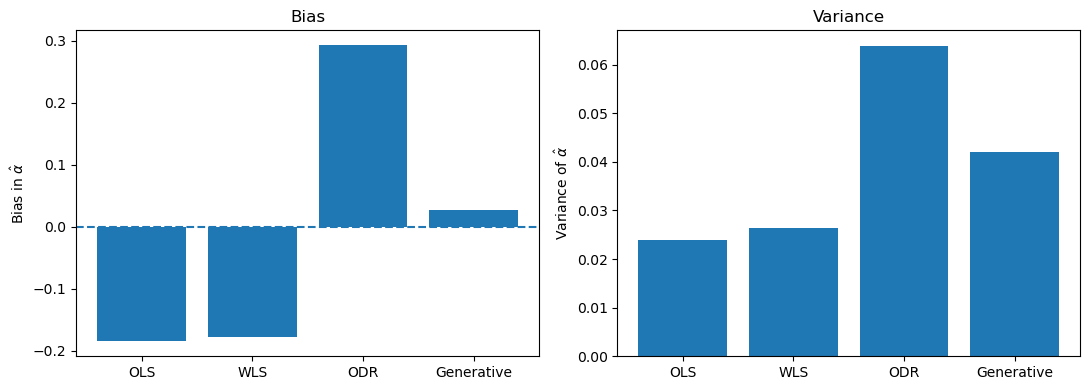

In [17]:
names = list(alpha_results.keys())

biases = np.array([
    np.mean(alpha_results[name]) - truth["alpha"]
    for name in names
])

variances = np.array([
    np.var(alpha_results[name], ddof=1)
    for name in names
])


fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar(names, biases)
ax[0].axhline(0, linestyle="--")
ax[0].set_ylabel(r"Bias in $\hat{\alpha}$")
ax[0].set_title("Bias")

ax[1].bar(names, variances)
ax[1].set_ylabel(r"Variance of $\hat{\alpha}$")
ax[1].set_title("Variance")

plt.tight_layout()
plt.show()

In [18]:
NCOV = 100

cover_alpha = []
cover_beta = []
cover_sint = []

for k in range(NCOV):

    xs, ys, _, _ = simulate_dataset(
        truth["alpha"],
        truth["beta"],
        truth["sigma_int"],
        truth["mu"],
        truth["sigma_pop"],
        sx,
        sy
    )

    try:

        fit = fit_generative(
            xs,
            ys,
            sx,
            sy,
            get_uncertainty=True
        )

        (
            a,
            b,
            sint,
            muhat,
            spophat,
            sa,
            sb,
            ssint
        ) = fit

        cover_alpha.append(
            abs(a - truth["alpha"]) <= sa
        )

        cover_beta.append(
            abs(b - truth["beta"]) <= sb
        )

        cover_sint.append(
            abs(sint - truth["sigma_int"]) <= ssint
        )

    except (np.linalg.LinAlgError, ValueError):
        # skip rare failed Hessian inversion
        continue


print("COVERAGE")
print(f"usable simulations = {len(cover_alpha)}")
print()

print(
    f"alpha coverage     = {np.mean(cover_alpha):.3f}"
)

print(
    f"beta coverage      = {np.mean(cover_beta):.3f}"
)

print(
    f"sigma_int coverage = {np.mean(cover_sint):.3f}"
)

COVERAGE
usable simulations = 100

alpha coverage     = 0.630
beta coverage      = 0.640
sigma_int coverage = 0.770


In [19]:
NSENS = 100

sensitivity_xerr = {
    "0.5x errors": [],
    "correct errors": [],
    "1.5x errors": []
}

for k in range(NSENS):

    xs, ys, _, _ = simulate_dataset(
        truth["alpha"],
        truth["beta"],
        truth["sigma_int"],
        truth["mu"],
        truth["sigma_pop"],
        sx,
        sy
    )

    a, *_ = fit_generative(
        xs,
        ys,
        0.5 * sx,
        sy
    )

    sensitivity_xerr["0.5x errors"].append(a)


    a, *_ = fit_generative(
        xs,
        ys,
        sx,
        sy
    )

    sensitivity_xerr["correct errors"].append(a)


    a, *_ = fit_generative(
        xs,
        ys,
        1.5 * sx,
        sy
    )

    sensitivity_xerr["1.5x errors"].append(a)

In [20]:
print("X-ERROR SENSITIVITY")
print()

for name, vals in sensitivity_xerr.items():

    vals = np.array(vals)

    print(
        f"{name:15s}: "
        f"mean alpha = {vals.mean():.4f}, "
        f"bias = {vals.mean() - truth['alpha']:.4f}"
    )

X-ERROR SENSITIVITY

0.5x errors    : mean alpha = 1.0025, bias = -0.1377
correct errors : mean alpha = 1.1630, bias = 0.0228
1.5x errors    : mean alpha = 1.4774, bias = 0.3371


In [21]:
alpha_uniform = []

for k in range(NSENS):

    xs, ys, _, _ = simulate_dataset(
        truth["alpha"],
        truth["beta"],
        truth["sigma_int"],
        truth["mu"],
        truth["sigma_pop"],
        sx,
        sy,
        population="uniform"
    )

    a, *_ = fit_generative(
        xs,
        ys,
        sx,
        sy
    )

    alpha_uniform.append(a)


alpha_uniform = np.array(alpha_uniform)

print("NON-GAUSSIAN POPULATION")

print(
    f"mean alpha = {alpha_uniform.mean():.4f}"
)

print(
    f"bias = "
    f"{alpha_uniform.mean() - truth['alpha']:.4f}"
)

NON-GAUSSIAN POPULATION
mean alpha = 1.1804
bias = 0.0402


In [22]:
def generative_nll_no_intrinsic(
    params,
    xobs,
    yobs,
    sx_fit,
    sy_fit
):

    alpha, beta, mu, log_sigma_pop = params

    sigma_pop = np.exp(log_sigma_pop)

    vpop = sigma_pop**2

    mean_x = mu
    mean_y = alpha * (mu - 9.5) + beta

    dx = xobs - mean_x
    dy = yobs - mean_y

    Vxx = vpop + sx_fit**2

    Vxy = alpha * vpop

    Vyy = (
        alpha**2 * vpop
        + sy_fit**2
    )

    det = Vxx * Vyy - Vxy**2

    if np.any(det <= 0):
        return np.inf

    quad = (
        Vyy * dx**2
        - 2 * Vxy * dx * dy
        + Vxx * dy**2
    ) / det

    return 0.5 * np.sum(
        np.log(det)
        + quad
        + 2*np.log(2*np.pi)
    )


def fit_no_intrinsic(
    xobs,
    yobs,
    sx_fit,
    sy_fit
):

    a0, b0 = fit_odr(
        xobs,
        yobs,
        sx_fit,
        sy_fit
    )

    spop0 = np.sqrt(
        max(
            np.var(xobs, ddof=1)
            - np.mean(sx_fit**2),
            0.1**2
        )
    )

    p0 = [
        a0,
        b0,
        np.mean(xobs),
        np.log(spop0)
    ]

    result = minimize(
        generative_nll_no_intrinsic,
        p0,
        args=(
            xobs,
            yobs,
            sx_fit,
            sy_fit
        ),
        method="BFGS"
    )

    alpha, beta, mu, log_spop = result.x

    return (
        alpha,
        beta,
        mu,
        np.exp(log_spop)
    )

In [23]:
alpha_no_scatter = []

for k in range(NSENS):

    xs, ys, _, _ = simulate_dataset(
        truth["alpha"],
        truth["beta"],
        truth["sigma_int"],
        truth["mu"],
        truth["sigma_pop"],
        sx,
        sy
    )

    a, *_ = fit_no_intrinsic(
        xs,
        ys,
        sx,
        sy
    )

    alpha_no_scatter.append(a)


alpha_no_scatter = np.array(alpha_no_scatter)

print("ASSUME sigma_int = 0")

print(
    f"mean alpha = {alpha_no_scatter.mean():.4f}"
)

print(
    f"bias = "
    f"{alpha_no_scatter.mean() - truth['alpha']:.4f}"
)

ASSUME sigma_int = 0
mean alpha = 1.3684
bias = 0.2282


**WHAT THE CHECKS FOUND:**

*your report goes here*

### What the checks found

**Closure.**  
The generative fit recovered the simulated truth reasonably well. For
$\alpha$, the true value was 1.140 and the recovered value was
$1.241 \pm 0.214$. For $\beta$, the true value was 5.921 and the recovered
value was $5.836 \pm 0.114$. For $\sigma_{\rm int}$, the true value was
0.494 dex and the recovered value was $0.431 \pm 0.106$ dex. The differences
from the truth were 0.47, -0.75, and -0.59 reported standard deviations,
respectively. All three true values were therefore within one reported
standard deviation of the fitted values, so the closure test did not reveal
an obvious problem with the implementation.

**Bias and efficiency.**  
Across 200 simulated datasets, with a true slope of $\alpha=1.1402$, the mean
recovered slopes were 0.9550 for OLS, 0.9615 for WLS, 1.4332 for ODR, and
1.1668 for the generative model. Their biases were -0.1852, -0.1787,
+0.2930, and +0.0266, respectively. OLS and WLS both underestimated the
slope, consistent with attenuation bias caused by ignoring the measurement
errors in $x$. Weighting by the $y$ errors alone therefore did not remove
this bias. ODR instead overestimated the slope in these simulations, while
the generative estimator had the smallest bias. The variances of
$\hat{\alpha}$ were 0.0238 for OLS, 0.0264 for WLS, 0.0639 for ODR, and
0.0421 for the generative model. Thus OLS and WLS had smaller variance but
were systematically biased, while the generative model traded somewhat
larger variance for much smaller bias.

**Coverage.**  
The empirical 68% coverage fractions from 100 simulations were 0.630 for
$\alpha$, 0.640 for $\beta$, and 0.770 for $\sigma_{\rm int}$. Given the
finite number of simulations, these are reasonably close to the nominal 68%
coverage, although the $\sigma_{\rm int}$ interval appears somewhat
conservative in this experiment. Overall, the curvature-based uncertainties
do not show a severe coverage failure.

**Sensitivity.**  
The inferred slope was strongly sensitive to the assumed $x$ measurement
errors. When the errors used in the fit were reduced to 0.5 times their true
values, the mean recovered slope was 1.0025, with a bias of -0.1377. With
the correct errors, the mean was 1.1630, with a bias of +0.0228. Increasing
the assumed errors to 1.5 times their true values increased the mean slope
to 1.4774, with a bias of +0.3371. Therefore underestimating the $x$ errors
leads to insufficient correction of attenuation, while overestimating them
can make the inferred relation too steep.

Replacing the Gaussian latent-$x$ population with a uniform distribution
having the same mean and variance produced a mean slope of 1.1804, corresponding
to a relatively small bias of +0.0402. The slope is therefore fairly robust
to this particular violation of the Gaussian population assumption. In
contrast, incorrectly forcing $\sigma_{\rm int}=0$ produced a mean slope of
1.3684, with a bias of +0.2282. Ignoring the intrinsic scatter therefore
produced a substantial upward bias in the inferred slope. Among these tests,
the slope was most sensitive to mis-specified $x$ uncertainties and to
ignoring intrinsic scatter, and was much less sensitive to the Gaussian
shape assumed for the latent $x$ population.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

*your answer goes here*

I used ChatGPT to help me interpret the statistical methods in the lab, write and
debug Python code for the OLS, WLS, ODR, generative-model, and verification
sections, and improve the wording of my explanations.

I did not treat the AI output as automatically correct. For example, ChatGPT
initially suggested that ODR should reduce the attenuation bias and generally
move the slope closer to the true value. My Monte Carlo test showed that this
was not true for my simulated data: ODR had a positive slope bias of about
+0.293, while the generative model had a much smaller bias of about +0.027.
I caught this by running the bias/variance simulations and changed my
interpretation to match the actual results rather than the AI's initial
expectation.

I also checked the generative-model implementation using the closure test,
coverage test, and sensitivity tests required in Part 3. These checks were useful
for verifying that the code recovered known simulated parameters reasonably
well and for identifying which assumptions had the largest effect on the fitted
slope. I used ChatGPT mainly as a coding and explanation aid, while the numerical
results reported in the lab came from running and checking the code in my own
notebook.